In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('amazon_review_dataset.csv')

df.head()

,review,sentiment
0,No issues.,positive
1,"Purchased this for my device, it worked as adv...",positive
2,it works as expected. I should have sprung for...,positive
3,This think has worked out great.Had a diff. br...,positive
4,"Bought it with Retail Packaging, arrived legit...",positive


# EDA

In [5]:
# shape 
print(df.shape,"\n")

# info 
print(df.info(),'\n')

# duplicates
print(df.duplicated().sum(),'\n')

# drop duplicates
print(df.drop_duplicates(inplace=True),'\n')

# value counts of sentiment
print(df['sentiment'].value_counts(),'\n')

# null values
print(df.isna().sum(),'\n')

# drop null values
print(df.dropna(inplace=True),'\n')



(4915, 2) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     4914 non-null   object
 1   sentiment  4915 non-null   object
dtypes: object(2)
memory usage: 76.9+ KB
None 

2 

None 

sentiment
positive    4447
negative     466
Name: count, dtype: int64 

review       1
sentiment    0
dtype: int64 

None 



In [ ]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 4.2 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 3.5 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\lokes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lokes\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lokes\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

In [8]:

def normalize_text(text):

    # 1. changing text to lower case
    text = str(text).lower()

    # 2. Remove urls
    text = re.sub(r'https?://\s+|www\.\S+','',text)

    # remove html tags
    text = re.sub(r'<.*>','',text)

    # 4. reomve emojis and special characters (keep only a-z spaces)
    text = re.sub(r'[^a-z\s]','',text)

    # 5. Remove extra whitespaces

    text = " ".join(text.split())
    
    return text

def remove_noise(word_list):
    clean_tokens = [re.sub(r'[^A-Za-z0-9]+','',word) for word in word_list]

    return [word for word in clean_tokens if word]


def remove_stopwords(word_list):
    filtered_tokens = [word for word in word_list if word not in stop_words]
    return filtered_tokens

def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]


df['review'] = df['review'].apply(normalize_text)
df['review'] = df['review'].apply(word_tokenize)
df['review'] = df['review'].apply(remove_noise)
df['review'] = df['review'].apply(remove_stopwords)
df['review'] = df['review'].apply(lemmatize_text)

print(df['review'].iloc[0:4])

df["review"] = df['review'].apply(lambda x : ' '.join(x))



0                                              [issue]
1    [purchased, device, worked, advertised, never,...
2    [work, expected, sprung, higher, capacity, thi...
3    [think, worked, greathad, diff, bran, gb, card...
Name: review, dtype: object


In [9]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

In [10]:
x_text = df['review']
y = df['sentiment']

In [11]:
print(len(x_text))
print(len(y))

4912
4912


In [12]:
vectorizer = TfidfVectorizer(
    min_df= 5,
    max_df=0.9,
    ngram_range=(1,2)
)

In [13]:
x = vectorizer.fit_transform(x_text)

In [14]:
print('Shape of the vectorizer matrix :\n',x.shape)

Shape of the vectorizer matrix :
 (4912, 4725)


In [15]:
# total no of features
print(len(vectorizer.get_feature_names_out()))

4725


In [16]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print("shape of the x_test : \n",x_test.shape)
print("shape of the x_train : \n",x_train.shape)
print("shape of the y_train : \n",y_train.shape)
print("shape of the y_test : \n",y_test.shape)

shape of the x_test : 
 (983, 4725)
shape of the x_train : 
 (3929, 4725)
shape of the y_train : 
 (3929,)
shape of the y_test : 
 (983,)


In [18]:
print(y_train.value_counts()['positive']/len(y_train))
print(y_train.value_counts()['negative']/len(y_train))
print(y_test.value_counts()['negative']/len(y_test))
print(y_test.value_counts()['positive']/len(y_test))

0.9050649020106898
0.09493509798931025
0.09460834181078331
0.9053916581892166


In [19]:
import joblib

joblib.dump(vectorizer,'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [20]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

In [21]:
lr_model.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [22]:
cv_scores = cross_val_score(
    lr_model,
    x_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

In [23]:
print("Fold Scores:", cv_scores)
print("Average F1:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Fold Scores: [0.92800458 0.92993516 0.92519699 0.93388857 0.94609234]
Average F1: 0.932623524583289
Std Dev: 0.00730376174115932


In [24]:
y_pred = lr_model.predict(x_test)

In [25]:
accuracy = accuracy_score(
    y_test,y_pred
)

precision = precision_score(
    y_test,y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,y_pred,
    average='weighted'
)

f1_score = f1_score(
    y_test,y_pred,
    average='weighted'
)

cl_report = classification_report(
    y_test,y_pred
)

In [26]:
print("accuracy : ",accuracy,'\n')
print("precision : ",precision,'\n')
print("recall : ",recall,'\n')
print("f1_score : ",f1_score,'\n')
print("classification report : ",cl_report,'\n')

accuracy :  0.9114954221770092 

precision :  0.9264238173300161 

recall :  0.9114954221770092 

f1_score :  0.9173276705873911 

classification report :                precision    recall  f1-score   support

    negative       0.52      0.71      0.60        93
    positive       0.97      0.93      0.95       890

    accuracy                           0.91       983
   macro avg       0.75      0.82      0.78       983
weighted avg       0.93      0.91      0.92       983
 



In [31]:
joblib.dump(
    lr_model,
    "sentiment_model.pkl"
)

['sentiment_model.pkl']

In [27]:
review = [
    "This product is amazing and battery life is excellent"
]

review_vector = vectorizer.transform(review)

prediction = lr_model.predict(
    review_vector
)

print(prediction)

['positive']


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 4725)>

In [30]:
X_all = vectorizer.transform(df['review'])

df['predicted_sentiment'] = lr_model.predict(X_all)

In [34]:
positive_reviews = df[
    df['predicted_sentiment'] == 'positive'
]['review']

negative_reviews = df[
    df['predicted_sentiment'] == 'negative'
]['review']

print("Positive Reviews:", len(positive_reviews))
print("Negative Reviews:", len(negative_reviews))

Positive Reviews: 4274
Negative Reviews: 638


In [37]:
def extract_themes(reviews, top_n=20):

    tfidf = TfidfVectorizer(
        stop_words='english',
        ngram_range=(2,3),
        min_df=2,
        max_df=0.8
    )

    X = tfidf.fit_transform(reviews)

    feature_names = tfidf.get_feature_names_out()

    scores = X.mean(axis=0).A1

    themes = pd.DataFrame({
        'theme': feature_names,
        'score': scores
    })

    themes = themes.sort_values(
        by='score',
        ascending=False
    )

    return themes.head(top_n)

# ==========================================
# EXTRACT POSITIVE THEMES
# ==========================================

positive_themes = extract_themes(
    positive_reviews,
    top_n=20
)

print("\n")
print("=" * 60)
print("TOP POSITIVE THEMES")
print("=" * 60)

print(positive_themes)

# ==========================================
# EXTRACT NEGATIVE THEMES
# ==========================================





TOP POSITIVE THEMES
                     theme     score
10567           work great  0.017526
5369           memory card  0.016477
8324               sd card  0.016415
8014        samsung galaxy  0.012647
5570              micro sd  0.009766
1581             card work  0.008388
3315           galaxy note  0.008049
4056           great price  0.006926
10521            work fine  0.006549
5572         micro sd card  0.006501
10677       work perfectly  0.005718
5599          microsd card  0.005425
3429               gb card  0.005138
3752            good price  0.004916
3828            gopro hero  0.004748
9662        transfer speed  0.004317
8034   samsung galaxy note  0.004260
3374            galaxy tab  0.003925
1641            cell phone  0.003914
4354      highly recommend  0.003858


In [38]:
negative_themes = extract_themes(
    negative_reviews,
    top_n=20
)

print("\n")
print("=" * 60)
print("TOP NEGATIVE THEMES")
print("=" * 60)

print(negative_themes)



TOP NEGATIVE THEMES
                theme     score
2308          sd card  0.032319
1547      memory card  0.024546
1078          gb card  0.020333
2180   samsung galaxy  0.014911
1059      galaxy note  0.013324
1572     microsd card  0.013205
1565         micro sd  0.012476
2958      write speed  0.012227
2484  stopped working  0.009398
1567    micro sd card  0.009299
403        card phone  0.009283
2901      worked fine  0.009154
550         card work  0.008628
829         dont know  0.007890
2428         speed mb  0.007602
589        class card  0.007287
996       format card  0.007203
67      android phone  0.007106
554       card worked  0.007058
2276    sandisk ultra  0.007036


In [39]:
positive_themes.to_csv(
    "positive_themes.csv",
    index=False
)

negative_themes.to_csv(
    "negative_themes.csv",
    index=False
)

print("\nTheme files saved successfully.")


Theme files saved successfully.


In [40]:
results = {
    "Total Reviews": len(df),
    "Positive Reviews": len(positive_reviews),
    "Negative Reviews": len(negative_reviews)
}

print(results)

{'Total Reviews': 4912, 'Positive Reviews': 4274, 'Negative Reviews': 638}


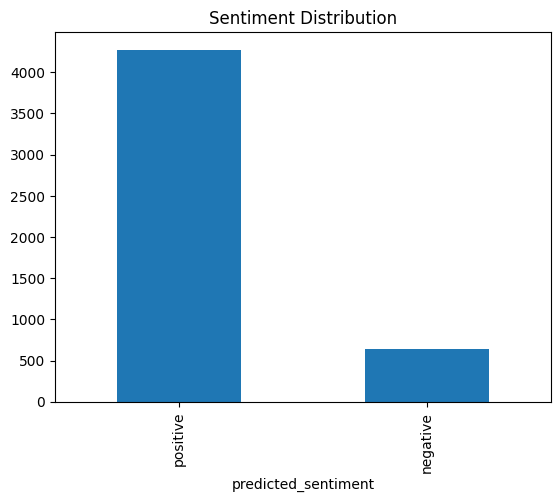

In [41]:
import matplotlib.pyplot as plt

df['predicted_sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")

plt.show()

<Axes: ylabel='theme'>

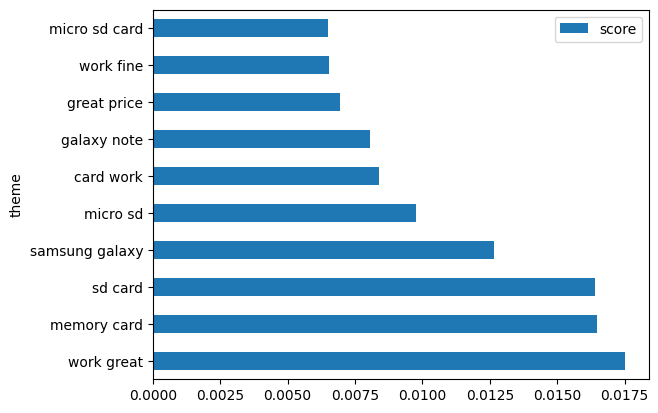

In [42]:
positive_themes.head(10).plot(
    x='theme',
    y='score',
    kind='barh'
)

<Axes: ylabel='theme'>

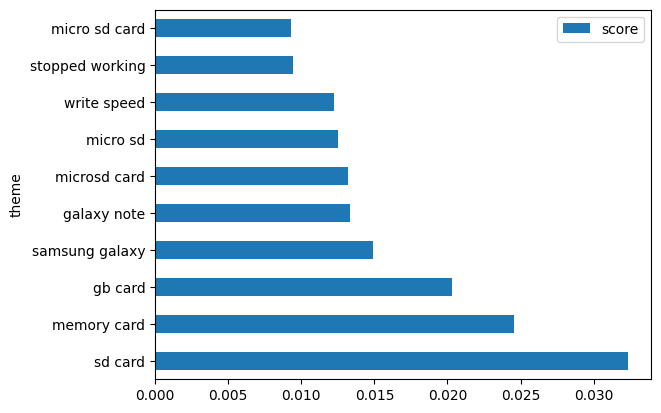

In [43]:
negative_themes.head(10).plot(
    x='theme',
    y='score',
    kind='barh'
)